In [73]:
library(data.table)
library(dplyr)
library(ggplot2)
library(qqman)
library(MASS)
library(meta)      # for meta-analysis functions
library(metafor)   # additional meta-analysis tools
library(gridExtra) # for multi-panel plots
options(repr.plot.width = 18, repr.plot.height = 15)

## Meta-Analysis of GWAS Studies (simulated BioGWAS data)

This notebook demonstrates **meta-GWAS**, the process of combining results from multiple independent GWAS studies to increase statistical power and identify genetic associations that may not be significant in individual studies.

Data used for this is simulated using BioGWAS (non-zero linkage diseq.)

### Meta-GWAS

combining statistics from multiple studies is good because:
- Leads to larger effective sample size
- Leads to detection of small effect sizes that individual studies can miss out on
- Validates findings across different populations or cohorts
- Looks at how consistent effects are across multiple studies.

**Challenges with doing this:**
- Studies may have different sample sizes
- Different ancestry backgrounds (allele frequencies vary)
- Different genotyping platforms
- Heterogeneous effect sizes

**Two Main Approaches:**
- **Fixed-Effects (FE)**: Assumes all studies estimate the same true effect
- **Random-Effects (RE)**: Allows true effects to vary across studies

### Meta-Analysis Statistical Framework

#### Fixed-Effects Model 
(weighted using Inverse-Variance)

Combines effect estimates weighted by their precision:

$$\beta_{\text{meta}} = \frac{\sum_{i=1}^{k} w_i \beta_i}{\sum_{i=1}^{k} w_i}$$

where $w_i = \frac{1}{SE_i^2}$ (inverse variance weight)

Standard error:
$$SE_{\text{meta}} = \sqrt{\frac{1}{\sum_{i=1}^{k} w_i}}$$

#### Heterogeneity Assessment

**Cochran's Q statistic** tests if effect sizes are homogeneous:
$$Q = \sum_{i=1}^{k} w_i (\beta_i - \beta_{\text{meta}})^2$$

**I² statistic** quantifies proportion of variance due to heterogeneity:
$$I^2 = \frac{Q - (k-1)}{Q} \times 100\%$$

- $I^2 < 25\%$: Low heterogeneity
- $I^2 = 25-75\%$: Moderate heterogeneity  
- $I^2 > 75\%$: High heterogeneity

### Simulation Strategy

We will simulate **4 independent GWAS studies** with:
1. **Different sample sizes** (500, 1000, 1500, 2000 participants)
2. **Different ancestry-like characteristics** (varying MAF distributions)
3. **Same true causal variants** (but different power to detect them)
4. **Linkage disequilibrium** (realistic correlation structure)
5. **Some heterogeneity** (effect sizes vary slightly across studies)


## Simulation Parameters

In [62]:
set.seed(37)

# Study-specific parameters
study_names <- c("Study_A", "Study_B", "Study_C", "Study_D")
sample_sizes <- c(500, 1000, 1500, 2000)  # Different statistical power
n_studies <- length(study_names)

# Common parameters across studies
n_snps <- 10000           # Number of SNPs
n_causal <- 15            # Number of true causal variants
heritability <- 0.4       # Genetic contribution to phenotype
ld_decay <- 0.95          # LD decay parameter
block_size <- 500         # For efficient LD simulation

cat("Meta-GWAS Simulation Setup:\n")
cat("  Number of studies:", n_studies, "\n")
cat("  Sample sizes:", paste(sample_sizes, collapse=", "), "\n")
cat("  Total participants:", sum(sample_sizes), "\n")
cat("  SNPs per study:", n_snps, "\n")
cat("  True causal variants:", n_causal, "\n")

Meta-GWAS Simulation Setup:
  Number of studies: 4 
  Sample sizes: 500, 1000, 1500, 2000 
  Total participants: 5000 
  SNPs per study: 10000 
  True causal variants: 15 


### Define Shared Causal Variants

All studies share the same underlying causal variants, but may have different power to detect them.

In [63]:
# Same causal SNPs across all studies
causal_snps <- sample(1:n_snps, n_causal)
cat("Causal SNP indices:", head(causal_snps, 10), "...\n")

Causal SNP indices: 5864 8813 6692 9652 7844 146 3292 3539 9233 5604 ...


### Simulate Study-Specific Characteristics

Different studies may have:
- Different minor allele frequencies (ancestry differences)
- Slight variations in effect sizes (heterogeneity)
- Different genotyping errors (noise levels)

In [64]:
# Generate study-specific MAF with ancestry-like differences
# Study A: European-like (MAF 0.05-0.5)
# Study B: East Asian-like (slightly different MAF distribution)
# Study C: African-like (higher MAF diversity)
# Study D: Latin American-like (intermediate)

study_mafs <- list(
  Study_A = runif(n_snps, min = 0.05, max = 0.45),
  Study_B = runif(n_snps, min = 0.08, max = 0.42),
  Study_C = runif(n_snps, min = 0.10, max = 0.50),
  Study_D = runif(n_snps, min = 0.06, max = 0.48)
)

# Generate study-specific effect sizes with some heterogeneity
# Base effects + study-specific variation
base_effects <- rnorm(n_causal, mean = 0, sd = 0.2)

study_effects <- list()
for (i in 1:n_studies) {
  # Add small random variation to create heterogeneity
  variation <- rnorm(n_causal, mean = 0, sd = 0.03)
  study_effects[[study_names[i]]] <- base_effects + variation
}

cat("Study-specific parameters generated\n")
cat("Average MAF ranges:\n")
for (name in study_names) {
  cat(sprintf("  %s: %.3f - %.3f\n", name, 
              min(study_mafs[[name]]), max(study_mafs[[name]])))
}

Study-specific parameters generated
Average MAF ranges:
  Study_A: 0.050 - 0.450
  Study_B: 0.080 - 0.420
  Study_C: 0.100 - 0.500
  Study_D: 0.060 - 0.480


## Simulate Individual GWAS Studies

workflow for each study (A,B, C and D)

```mermaid
    flowchart LR
    A[generate genotype matrix with LD] --> B["create phenotypes y = X Beta + ep."]
    B --> C[perform SNP-wise association testing]
    C --> D[store the summary stats]
```

this entire workflow is stored in the `simulate_gwas_study` function:

In [65]:
# Function to simulate one GWAS study with LD
simulate_gwas_study <- function(study_name, n_individuals, maf, 
                                 causal_indices, effect_sizes) {
  
  cat("\n========================================\n")
  cat("Simulating", study_name, "(N =", n_individuals, ")\n")
  cat("========================================\n")
  
  # 1. Generate genotypes with LD
  cat("Step 1: Generating genotypes with LD...\n")
  genotypes <- matrix(0, nrow = n_individuals, ncol = n_snps)
  n_blocks <- ceiling(n_snps / block_size)
  
  for (block in 1:n_blocks) {
    start_idx <- (block - 1) * block_size + 1
    end_idx <- min(block * block_size, n_snps)
    block_snps <- end_idx - start_idx + 1
    
    # Create LD correlation matrix
    Sigma <- matrix(1, nrow = block_snps, ncol = block_snps)
    for (i in 1:block_snps) {
      for (j in 1:block_snps) {
        if (i != j) {
          Sigma[i, j] <- ld_decay^abs(i - j)
        }
      }
    }
    
    # Generate correlated normal variables
    Z <- mvrnorm(n = n_individuals, mu = rep(0, block_snps), Sigma = Sigma)
    
    # Convert to genotypes using MAF-specific thresholds
    for (j in 1:block_snps) {
      snp_idx <- start_idx + j - 1
      p <- maf[snp_idx]
      
      threshold_0 <- qnorm((1-p)^2)
      threshold_1 <- qnorm((1-p)^2 + 2*p*(1-p))
      
      genotypes[, snp_idx] <- ifelse(Z[, j] < threshold_0, 0,
                                      ifelse(Z[, j] < threshold_1, 1, 2))
    }
    
    if (block %% 5 == 0) {
      cat(sprintf("  Block %d/%d complete\n", block, n_blocks))
    }
  }
  
  # 2. Generate phenotypes
  cat("Step 2: Generating phenotypes...\n")
  beta <- rep(0, n_snps)
  beta[causal_indices] <- effect_sizes
  
  genetic_score <- genotypes %*% beta
  var_g <- var(genetic_score)
  var_e <- var_g * (1 - heritability) / heritability
  environmental_noise <- rnorm(n_individuals, mean = 0, sd = sqrt(var_e))
  phenotype <- as.numeric(genetic_score + environmental_noise)
  
  # 3. Perform association testing
  cat("Step 3: Running association tests...\n")
  gwas_results <- lapply(1:n_snps, function(j) {
    if (j %% 2000 == 0) cat("  SNP", j, "/", n_snps, "\n")
    
    model <- lm(phenotype ~ genotypes[, j])
    summary_model <- summary(model)
    
    data.frame(
      beta = summary_model$coefficients[2, 1],
      se = summary_model$coefficients[2, 2],
      p_value = summary_model$coefficients[2, 4]
    )
  })
  
  gwas_results <- bind_rows(gwas_results)
  
  # Add metadata
  gwas_results <- gwas_results %>%
    mutate(
      SNP = paste0("rs", 1:n_snps),
      CHR = sample(1:22, n_snps, replace = TRUE),
      BP = cumsum(sample(1000:5000, n_snps, replace = TRUE)),
      N = n_individuals,
      study = study_name,
      is_causal = 1:n_snps %in% causal_indices
    )
  
  cat("Step 4: Summary statistics\n")
  cat("  Significant SNPs (p < 5e-8):", sum(gwas_results$p_value < 5e-8), "\n")
  cat("  Causal SNPs detected:", 
      sum(gwas_results$is_causal & gwas_results$p_value < 5e-8), "/", n_causal, "\n")
  
  return(list(
    results = gwas_results,
    genotypes = genotypes,
    phenotype = phenotype
  ))
}

cat("Function defined: simulate_gwas_study()\n")

Function defined: simulate_gwas_study()


### Run Simulations for All Studies

This will take a few minutes as we're simulating 4 complete GWAS studies with LD.

In [66]:
# Store all study results
all_studies <- list()

for (i in 1:n_studies) {
  study_data <- simulate_gwas_study(
    study_name = study_names[i],
    n_individuals = sample_sizes[i],
    maf = study_mafs[[i]],
    causal_indices = causal_snps,
    effect_sizes = study_effects[[i]]
  )
  
  all_studies[[study_names[i]]] <- study_data
}

cat("\n\n==========================================\n")
cat("ALL STUDIES SIMULATION COMPLETE!\n")
cat("==========================================\n")


Simulating Study_A (N = 500 )
Step 1: Generating genotypes with LD...
  Block 5/20 complete
  Block 10/20 complete
  Block 15/20 complete
  Block 20/20 complete
Step 2: Generating phenotypes...
Step 3: Running association tests...
  SNP 2000 / 10000 
  SNP 4000 / 10000 
  SNP 6000 / 10000 
  SNP 8000 / 10000 
  SNP 10000 / 10000 
Step 4: Summary statistics
  Significant SNPs (p < 5e-8): 15 
  Causal SNPs detected: 5 / 15 

Simulating Study_B (N = 1000 )
Step 1: Generating genotypes with LD...
  Block 5/20 complete
  Block 10/20 complete
  Block 15/20 complete
  Block 20/20 complete
Step 2: Generating phenotypes...
Step 3: Running association tests...
  SNP 2000 / 10000 
  SNP 4000 / 10000 
  SNP 6000 / 10000 
  SNP 8000 / 10000 
  SNP 10000 / 10000 
Step 4: Summary statistics
  Significant SNPs (p < 5e-8): 57 
  Causal SNPs detected: 4 / 15 

Simulating Study_C (N = 1500 )
Step 1: Generating genotypes with LD...
  Block 5/20 complete
  Block 10/20 complete
  Block 15/20 complete
  Blo

### Compare Individual Study Results

Below dataframe will illustrate the findings of each individual study:

Note: there are 15 true causal SNPs and even the best individual study could only detect 7 of them, this indicates that Meta-Analysis, ie, combining these studies might give us a chance to find more of them and get closer to finding all 15.

In [68]:
# Extract just the results dataframes
study_results_list <- lapply(all_studies, function(x) x$results)

# Summary table
summary_table <- data.frame(
  Study = study_names,
  N = sample_sizes,
  Significant = sapply(study_results_list, function(df) sum(df$p_value < 5e-8)),
  Causal_Detected = sapply(study_results_list, function(df) 
    sum(df$is_causal & df$p_value < 5e-8)),
  Detection_Rate = sapply(study_results_list, function(df) 
    round(100 * sum(df$is_causal & df$p_value < 5e-8) / n_causal, 1))
)

print(summary_table)

          Study    N Significant Causal_Detected Detection_Rate
Study_A Study_A  500          15               5           33.3
Study_B Study_B 1000          57               4           26.7
Study_C Study_C 1500          56               7           46.7
Study_D Study_D 2000          89               6           40.0


**Important Notes:**
- larger studies have a greater chance of detecting causal SNPs (associations)
- some causal variants arent detected in any of the four studies conducted.
- meta-analysis can improve this.

## Meta-Analysis: Combining Studies

Now we combine the evidence from all studies using meta-analysis.

#### Step 1: Harmonize Summary Statistics

Ensure all studies report effects for the same SNPs and alleles.

In [45]:
# Combine all results with study identifier
combined_results <- bind_rows(study_results_list)

# Check harmonization
cat("Combined dataset dimensions:", nrow(combined_results), "rows\n")
cat("Expected:", n_snps * n_studies, "rows\n")
cat("SNPs per study:", n_snps, "\n")
cat("Number of studies:", n_studies, "\n")

Combined dataset dimensions: 40000 rows
Expected: 40000 rows
SNPs per study: 10000 
Number of studies: 4 


#### Step 2: Fixed-Effects Meta-Analysis

Inverse-variance weighted combination of effect sizes.

In [69]:
# Perform fixed-effects meta-analysis for each SNP
cat("Performing fixed-effects meta-analysis...\n")

meta_results_fe <- combined_results %>%
  group_by(SNP) %>%
  summarise(
    CHR = first(CHR),
    BP = first(BP),
    is_causal = first(is_causal),
    
    # Fixed-effects: inverse-variance weighted
    beta_fe = sum(beta / se^2) / sum(1 / se^2),
    se_fe = sqrt(1 / sum(1 / se^2)),
    z_fe = beta_fe / se_fe,
    p_fe = 2 * pnorm(-abs(z_fe)),
    
    # Heterogeneity metrics
    n_studies = n(),
    Q = sum((1/se^2) * (beta - beta_fe)^2),
    df = n_studies - 1,
    p_het = pchisq(Q, df, lower.tail = FALSE),
    I2 = max(0, 100 * (Q - df) / Q),
    
    # Store individual study info for forest plots
    betas = list(beta),
    ses = list(se),
    studies = list(study),
    .groups = "drop"
  )

cat("Meta-analysis complete!\n")
cat("\nFixed-Effects Results:\n")
cat("  Genome-wide significant (p < 5e-8):", sum(meta_results_fe$p_fe < 5e-8), "\n")
cat("  Causal variants detected:", 
    sum(meta_results_fe$is_causal & meta_results_fe$p_fe < 5e-8), "/", n_causal, "\n")
cat("  Detection rate:", 
    round(100 * sum(meta_results_fe$is_causal & meta_results_fe$p_fe < 5e-8) / n_causal, 1), "%\n")

Performing fixed-effects meta-analysis...
Meta-analysis complete!

Fixed-Effects Results:
  Genome-wide significant (p < 5e-8): 196 
  Causal variants detected: 12 / 15 
  Detection rate: 80 %


#### Step 3: Assess Heterogeneity

Examine how consistent effect sizes are across studies.

In [70]:
# Heterogeneity summary for significant SNPs
significant_snps <- meta_results_fe %>%
  filter(p_fe < 5e-8) %>%
  arrange(p_fe)

if (nrow(significant_snps) == 0) {
  cat("\nNo genome-wide significant SNPs found (p < 5e-8)\n")
  cat("Consider using a more lenient threshold like p < 1e-5\n")
} else {
  cat("\nHeterogeneity Assessment (Significant SNPs):\n")
  cat("  Mean I²:", round(mean(significant_snps$I2), 1), "%\n")
  cat("  Median I²:", round(median(significant_snps$I2), 1), "%\n")
  cat("  SNPs with I² > 50%:", sum(significant_snps$I2 > 50), "\n")
  cat("  SNPs with I² > 75%:", sum(significant_snps$I2 > 75), "\n")
  
  # Show top SNPs with heterogeneity info
  cat("\nTop 10 Most Significant SNPs:\n")
  top_snps_display <- significant_snps %>%
    dplyr::select(SNP, CHR, BP, beta_fe, se_fe, p_fe, I2, is_causal) %>%
    head(10)
  
  print(as.data.frame(top_snps_display))
}


Heterogeneity Assessment (Significant SNPs):
  Mean I²: 32.5 %
  Median I²: 29.7 %
  SNPs with I² > 50%: 69 
  SNPs with I² > 75%: 17 

Top 10 Most Significant SNPs:
      SNP CHR       BP    beta_fe      se_fe          p_fe         I2 is_causal
1  rs2963  14  8911642  0.2591388 0.01136462 4.356276e-115 64.3866116      TRUE
2  rs2962   1  8907736  0.2067630 0.01123001  1.059444e-75 68.9076211     FALSE
3  rs2961   4  8904234  0.1790657 0.01048163  1.960876e-65 83.5473362     FALSE
4  rs7000  14 20962442 -0.2100175 0.01264458  5.968870e-62  0.9865628      TRUE
5  rs2964  15  8914203  0.2227797 0.01378360  9.247686e-59 63.4052685     FALSE
6  rs2960  22  8900734  0.1827124 0.01200961  2.861922e-52  0.0000000     FALSE
7  rs1647  16  4967651 -0.1649636 0.01102340  1.245812e-50 62.7552604      TRUE
8  rs2959   1  8897168  0.1749171 0.01195301  1.711319e-48 66.7205884     FALSE
9  rs2966   4  8921144  0.1884882 0.01295814  6.198196e-48  0.0000000     FALSE
10 rs4445   3 13358742 -0.1568003

#### Step 4: Random-Effects Meta-Analysis

For SNPs with substantial heterogeneity, random-effects may be more appropriate.

In [71]:
# Perform random-effects meta-analysis for heterogeneous SNPs
cat("Performing random-effects meta-analysis for heterogeneous SNPs...\n")

if (nrow(significant_snps) == 0) {
  cat("No significant SNPs to analyze with random-effects.\n")
} else {
  # DerSimonian-Laird random-effects for SNPs with high heterogeneity
  heterogeneous_snps <- meta_results_fe %>%
    filter(I2 > 25) %>%
    pull(SNP)
  
  cat("Number of heterogeneous SNPs (I² > 25%):", length(heterogeneous_snps), "\n")
  
  # For demonstration, calculate RE for top 20 significant SNPs
  top_snps <- significant_snps$SNP[1:min(20, nrow(significant_snps))]
  
  re_results <- lapply(top_snps, function(snp) {
    snp_data <- combined_results %>% filter(SNP == snp)
    
    # Use metafor package for random-effects
    tryCatch({
      re_model <- rma(yi = snp_data$beta, sei = snp_data$se, method = "DL")
      data.frame(
        SNP = snp,
        beta_re = as.numeric(re_model$b),
        se_re = as.numeric(re_model$se),
        p_re = as.numeric(re_model$pval),
        tau2 = as.numeric(re_model$tau2)
      )
    }, error = function(e) {
      data.frame(SNP = snp, beta_re = NA, se_re = NA, p_re = NA, tau2 = NA)
    })
  })
  
  re_results_df <- bind_rows(re_results)
  
  # Merge with fixed-effects results - only select non-list columns first
  comparison <- significant_snps %>%
    dplyr::select(SNP, CHR, BP, beta_fe, se_fe, p_fe, I2, is_causal) %>%
    left_join(re_results_df, by = "SNP") %>%
    head(10)
  
  cat("\nComparison: Fixed-Effects vs Random-Effects (Top 10 SNPs):\n")
  print(as.data.frame(comparison %>%
    dplyr::select(SNP, beta_fe, p_fe, beta_re, p_re, I2, is_causal)))
}

Performing random-effects meta-analysis for heterogeneous SNPs...
Number of heterogeneous SNPs (I² > 25%): 2634 

Comparison: Fixed-Effects vs Random-Effects (Top 10 SNPs):
      SNP    beta_fe          p_fe    beta_re         p_re         I2 is_causal
1  rs2963  0.2591388 4.356276e-115  0.2716945 2.252593e-39 64.3866116      TRUE
2  rs2962  0.2067630  1.059444e-75  0.2169380 5.833576e-24 68.9076211     FALSE
3  rs2961  0.1790657  1.960876e-65  0.1943290 1.854142e-12 83.5473362     FALSE
4  rs7000 -0.2100175  5.968870e-62 -0.2100495 3.223439e-61  0.9865628      TRUE
5  rs2964  0.2227797  9.247686e-59  0.2286237 2.286037e-22 63.4052685     FALSE
6  rs2960  0.1827124  2.861922e-52  0.1827124 2.861922e-52  0.0000000     FALSE
7  rs1647 -0.1649636  1.245812e-50 -0.1626728 2.262342e-16 62.7552604      TRUE
8  rs2959  0.1749171  1.711319e-48  0.1916527 1.852619e-16 66.7205884     FALSE
9  rs2966  0.1884882  6.198196e-48  0.1884882 6.198196e-48  0.0000000     FALSE
10 rs4445 -0.1568003  2.066

## Visualization: Meta-Analysis Results

#### Manhattan Plots: Individual Studies vs Meta-Analysis

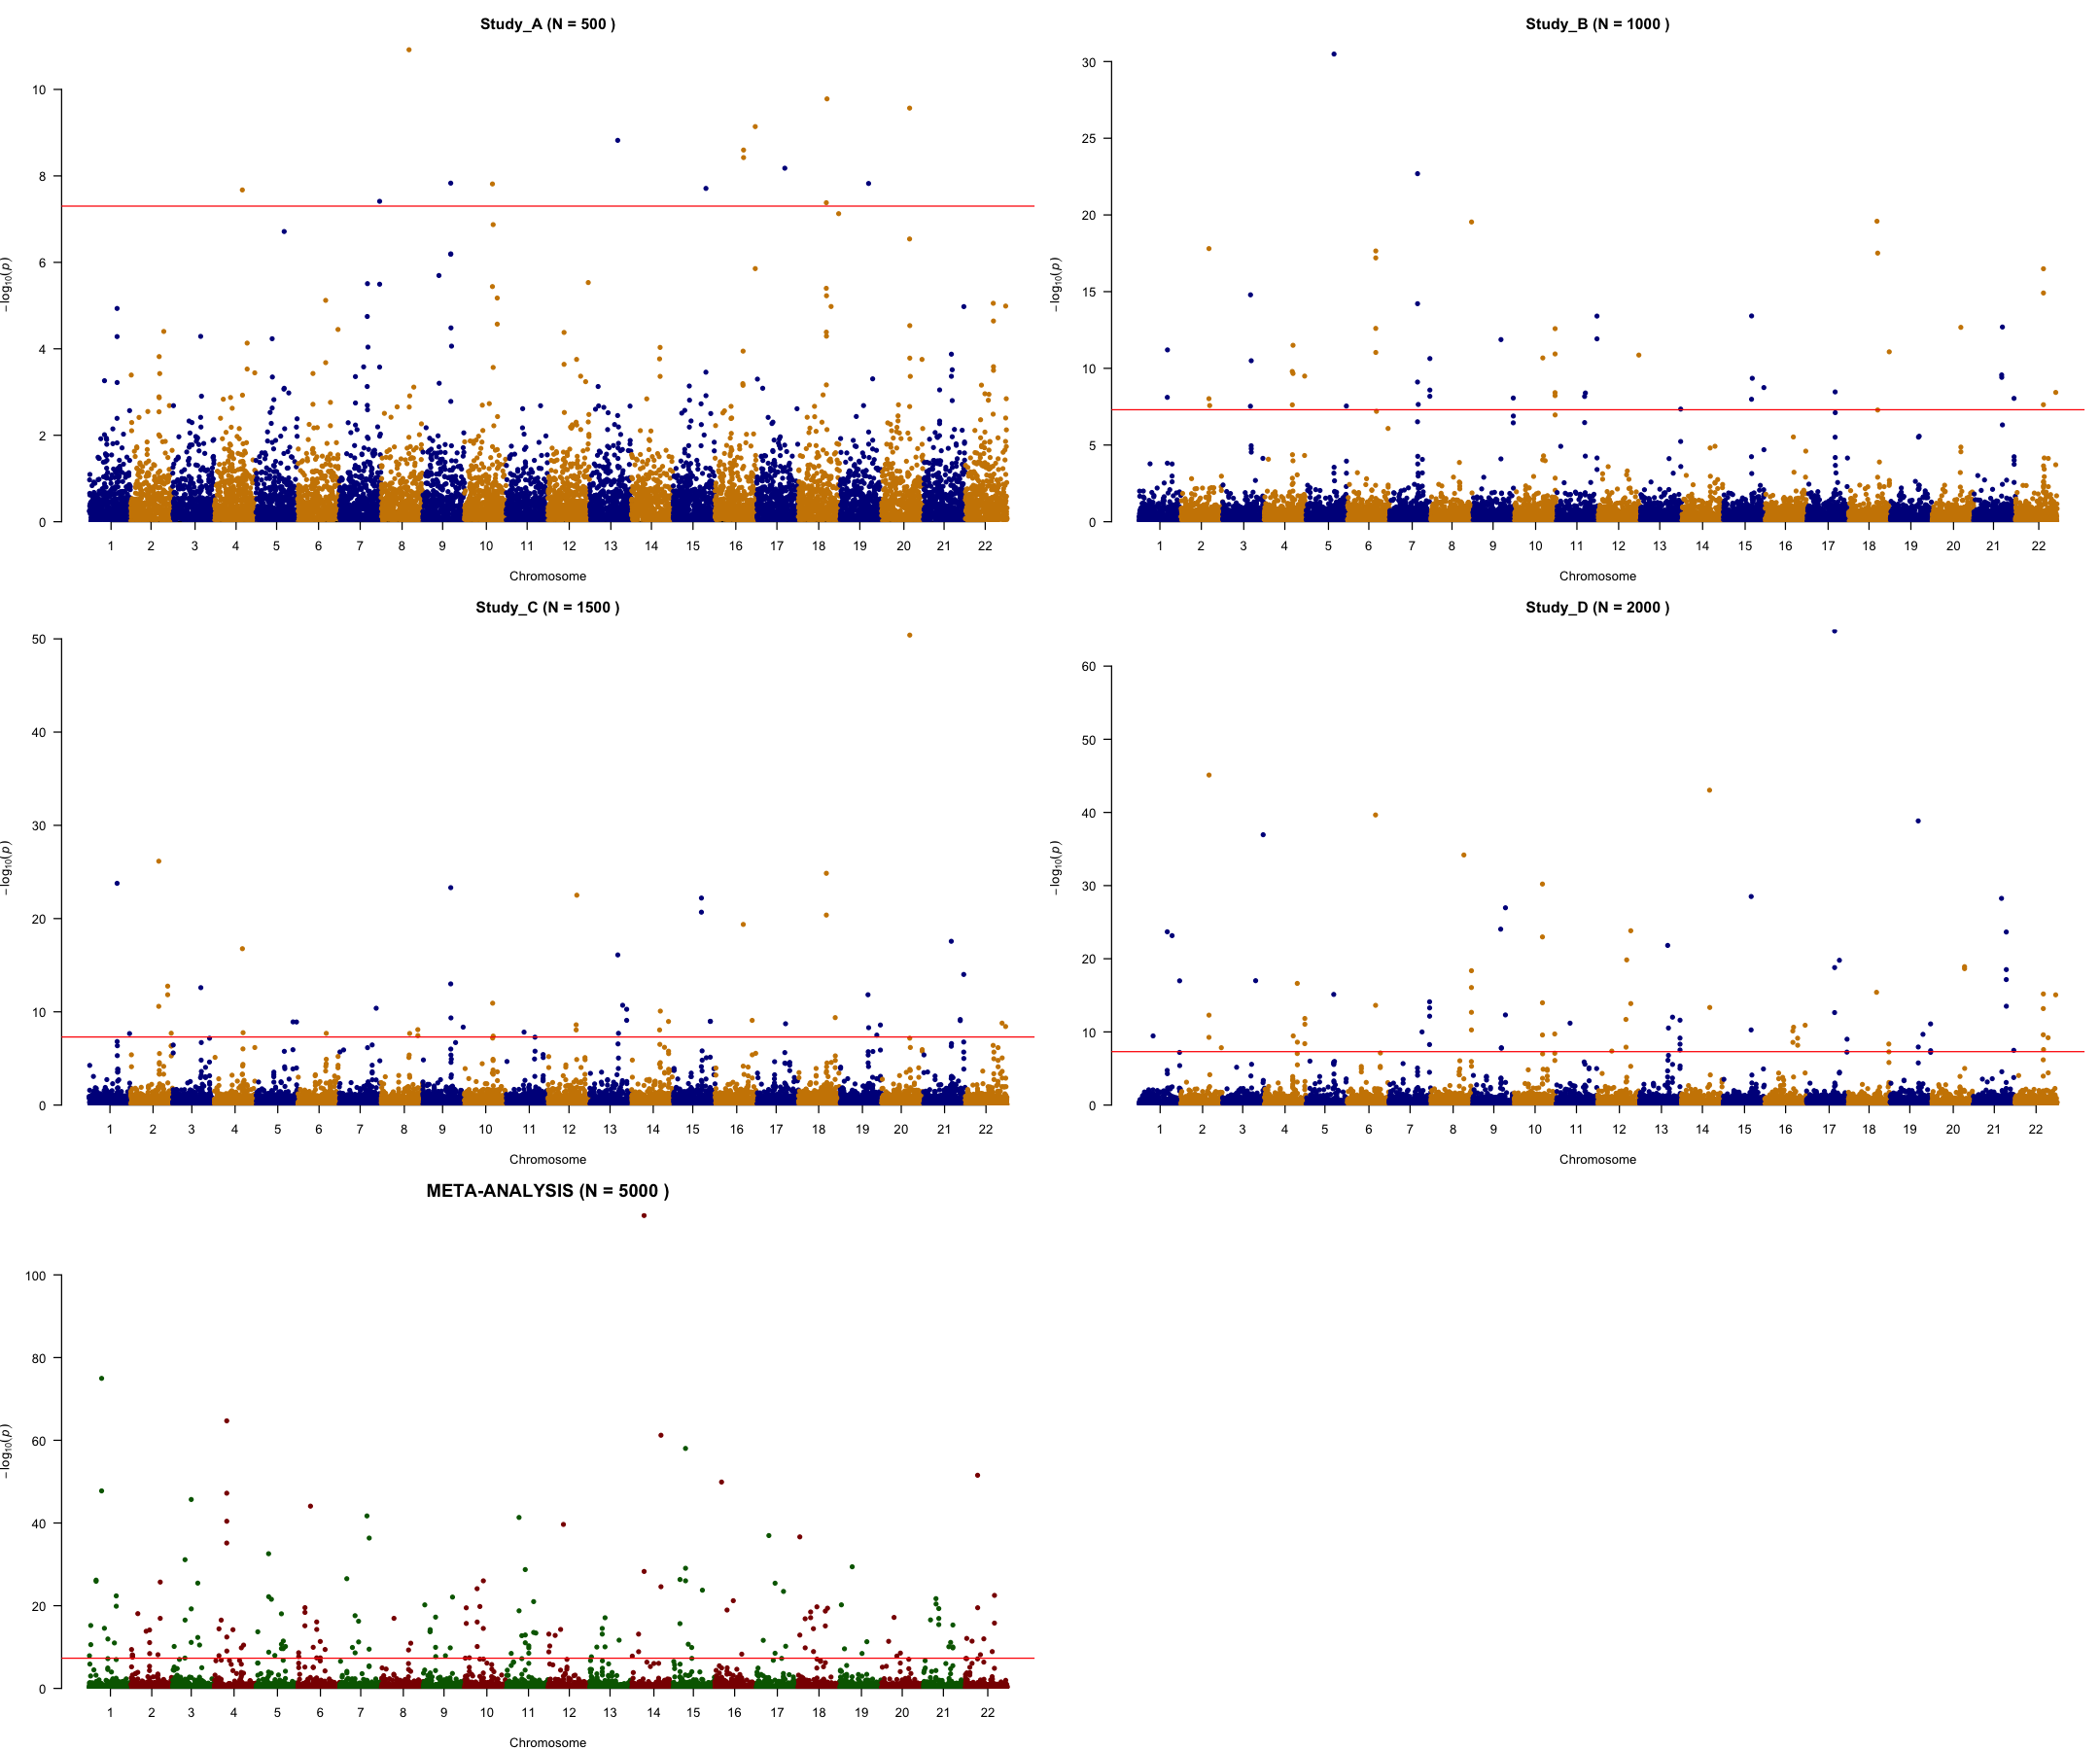

In [74]:
# Prepare data for multi-panel Manhattan plot
par(mfrow = c(3, 2), mar = c(4, 4, 3, 1))

# Individual studies
for (i in 1:n_studies) {
  study_df <- study_results_list[[i]]
  manhattan(
    study_df,
    chr = "CHR",
    bp = "BP",
    snp = "SNP",
    p = "p_value",
    genomewideline = -log10(5e-8),
    suggestiveline = FALSE,
    main = paste(study_names[i], "(N =", sample_sizes[i], ")"),
    col = c("blue4", "orange3"),
    cex.main = 1.2
  )
}

# Meta-analysis (Fixed-Effects)
manhattan(
  meta_results_fe,
  chr = "CHR",
  bp = "BP",
  snp = "SNP",
  p = "p_fe",
  genomewideline = -log10(5e-8),
  suggestiveline = FALSE,
  main = paste("META-ANALYSIS (N =", sum(sample_sizes), ")"),
  col = c("darkgreen", "darkred"),
  cex.main = 1.4
)

par(mfrow = c(1, 1))

#### Forest Plots: Study-Specific Effects

Forest plots visualize effect sizes and confidence intervals across studies for specific SNPs.

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”
`height` was translated to `width`.


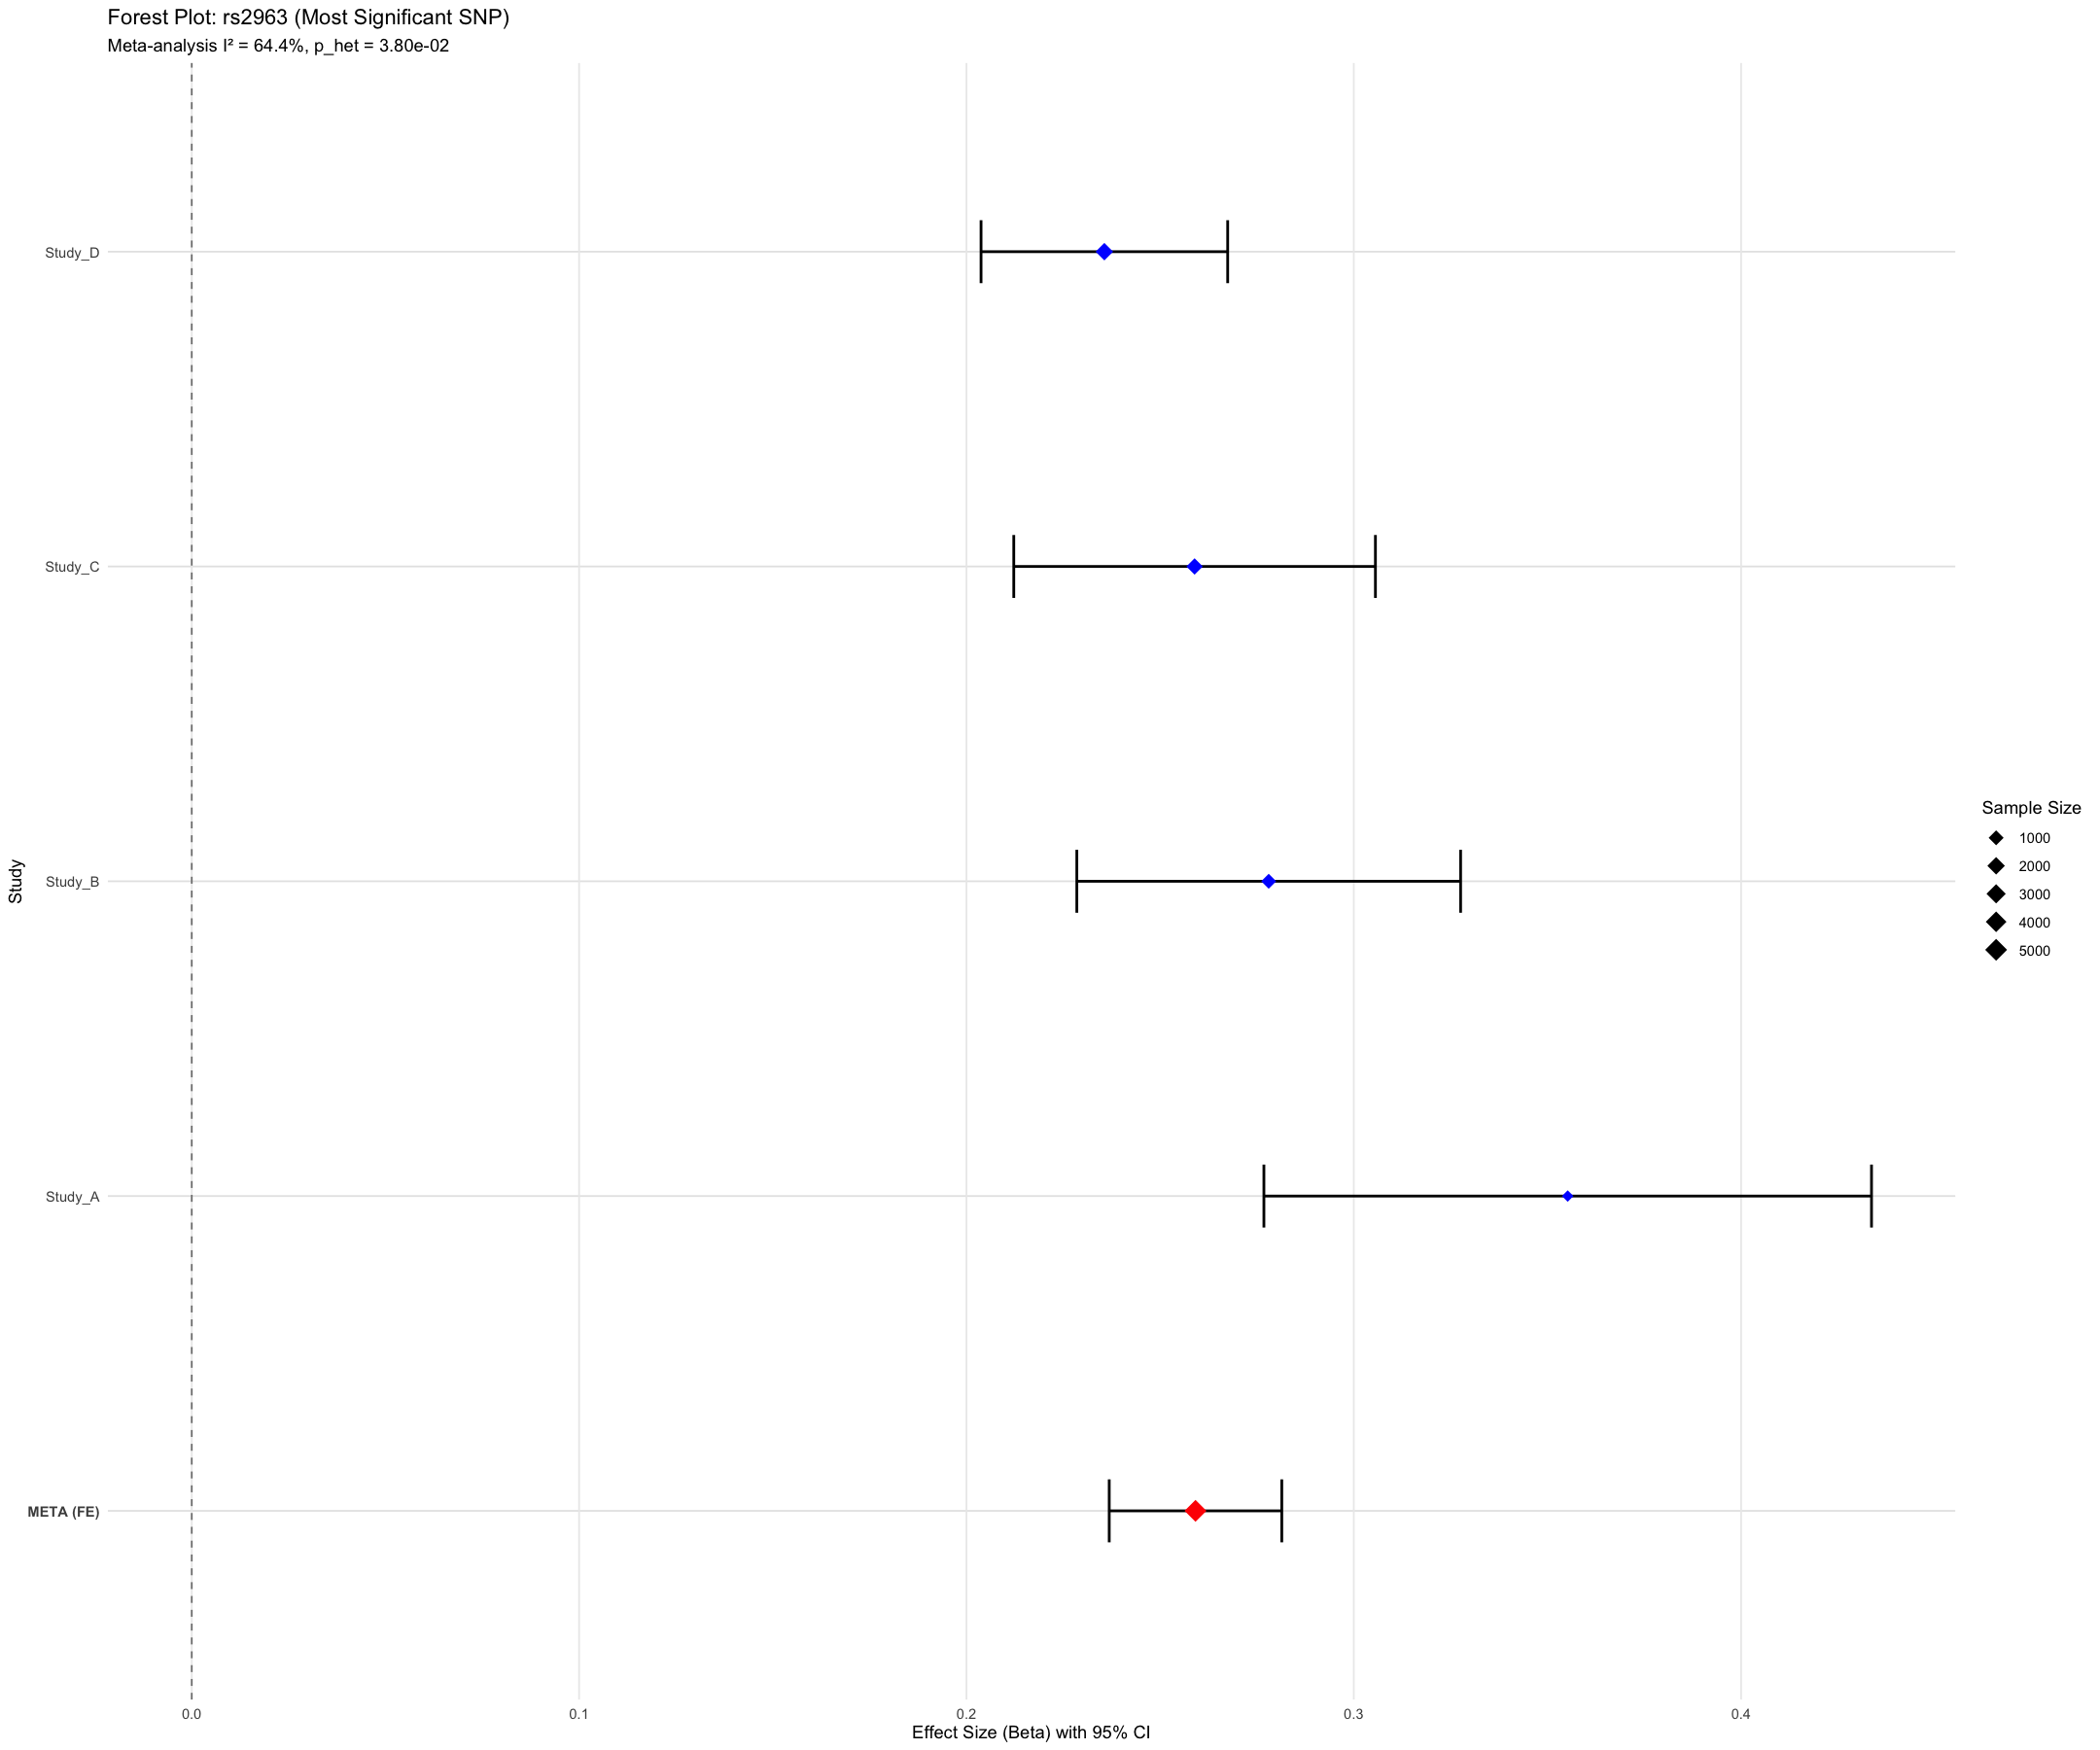

In [75]:
# Forest plot for the most significant SNP
if (nrow(significant_snps) == 0) {
  cat("No significant SNPs for forest plot.\n")
} else {
  top_snp <- significant_snps$SNP[1]
  
  snp_data <- combined_results %>% 
    filter(SNP == top_snp) %>%
    arrange(desc(N))
  
  # Get meta-analysis result
  meta_estimate <- meta_results_fe %>% filter(SNP == top_snp)
  
  # Create forest plot data
  forest_data <- snp_data %>%
    mutate(
      lower_ci = beta - 1.96 * se,
      upper_ci = beta + 1.96 * se
    ) %>%
    dplyr::select(study, beta, lower_ci, upper_ci, N)
  
  # Add meta-analysis row
  forest_data <- rbind(
    forest_data,
    data.frame(
      study = "META (FE)",
      beta = meta_estimate$beta_fe,
      lower_ci = meta_estimate$beta_fe - 1.96 * meta_estimate$se_fe,
      upper_ci = meta_estimate$beta_fe + 1.96 * meta_estimate$se_fe,
      N = sum(sample_sizes)
    )
  )
  
  forest_data$study <- factor(forest_data$study, levels = rev(forest_data$study))
  
  # Create forest plot
  print(ggplot(forest_data, aes(x = beta, y = study)) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
    geom_errorbarh(aes(xmin = lower_ci, xmax = upper_ci), height = 0.2, size = 0.8) +
    geom_point(aes(size = N, color = study == "META (FE)"), shape = 18) +
    scale_color_manual(values = c("blue", "red"), guide = "none") +
    scale_size_continuous(range = c(3, 6), name = "Sample Size") +
    theme_minimal() +
    theme(
      axis.text.y = element_text(face = ifelse(levels(forest_data$study) == "META (FE)", "bold", "plain")),
      panel.grid.major.y = element_line(color = "gray90"),
      panel.grid.minor = element_blank()
    ) +
    labs(
      title = sprintf("Forest Plot: %s (Most Significant SNP)", top_snp),
      subtitle = sprintf("Meta-analysis I² = %.1f%%, p_het = %.2e", 
                        meta_estimate$I2, meta_estimate$p_het),
      x = "Effect Size (Beta) with 95% CI",
      y = "Study"
    ))
}

#### Forest Plots for Multiple Top SNPs

`height` was translated to `width`.
`height` was translated to `width`.
`height` was translated to `width`.
`height` was translated to `width`.


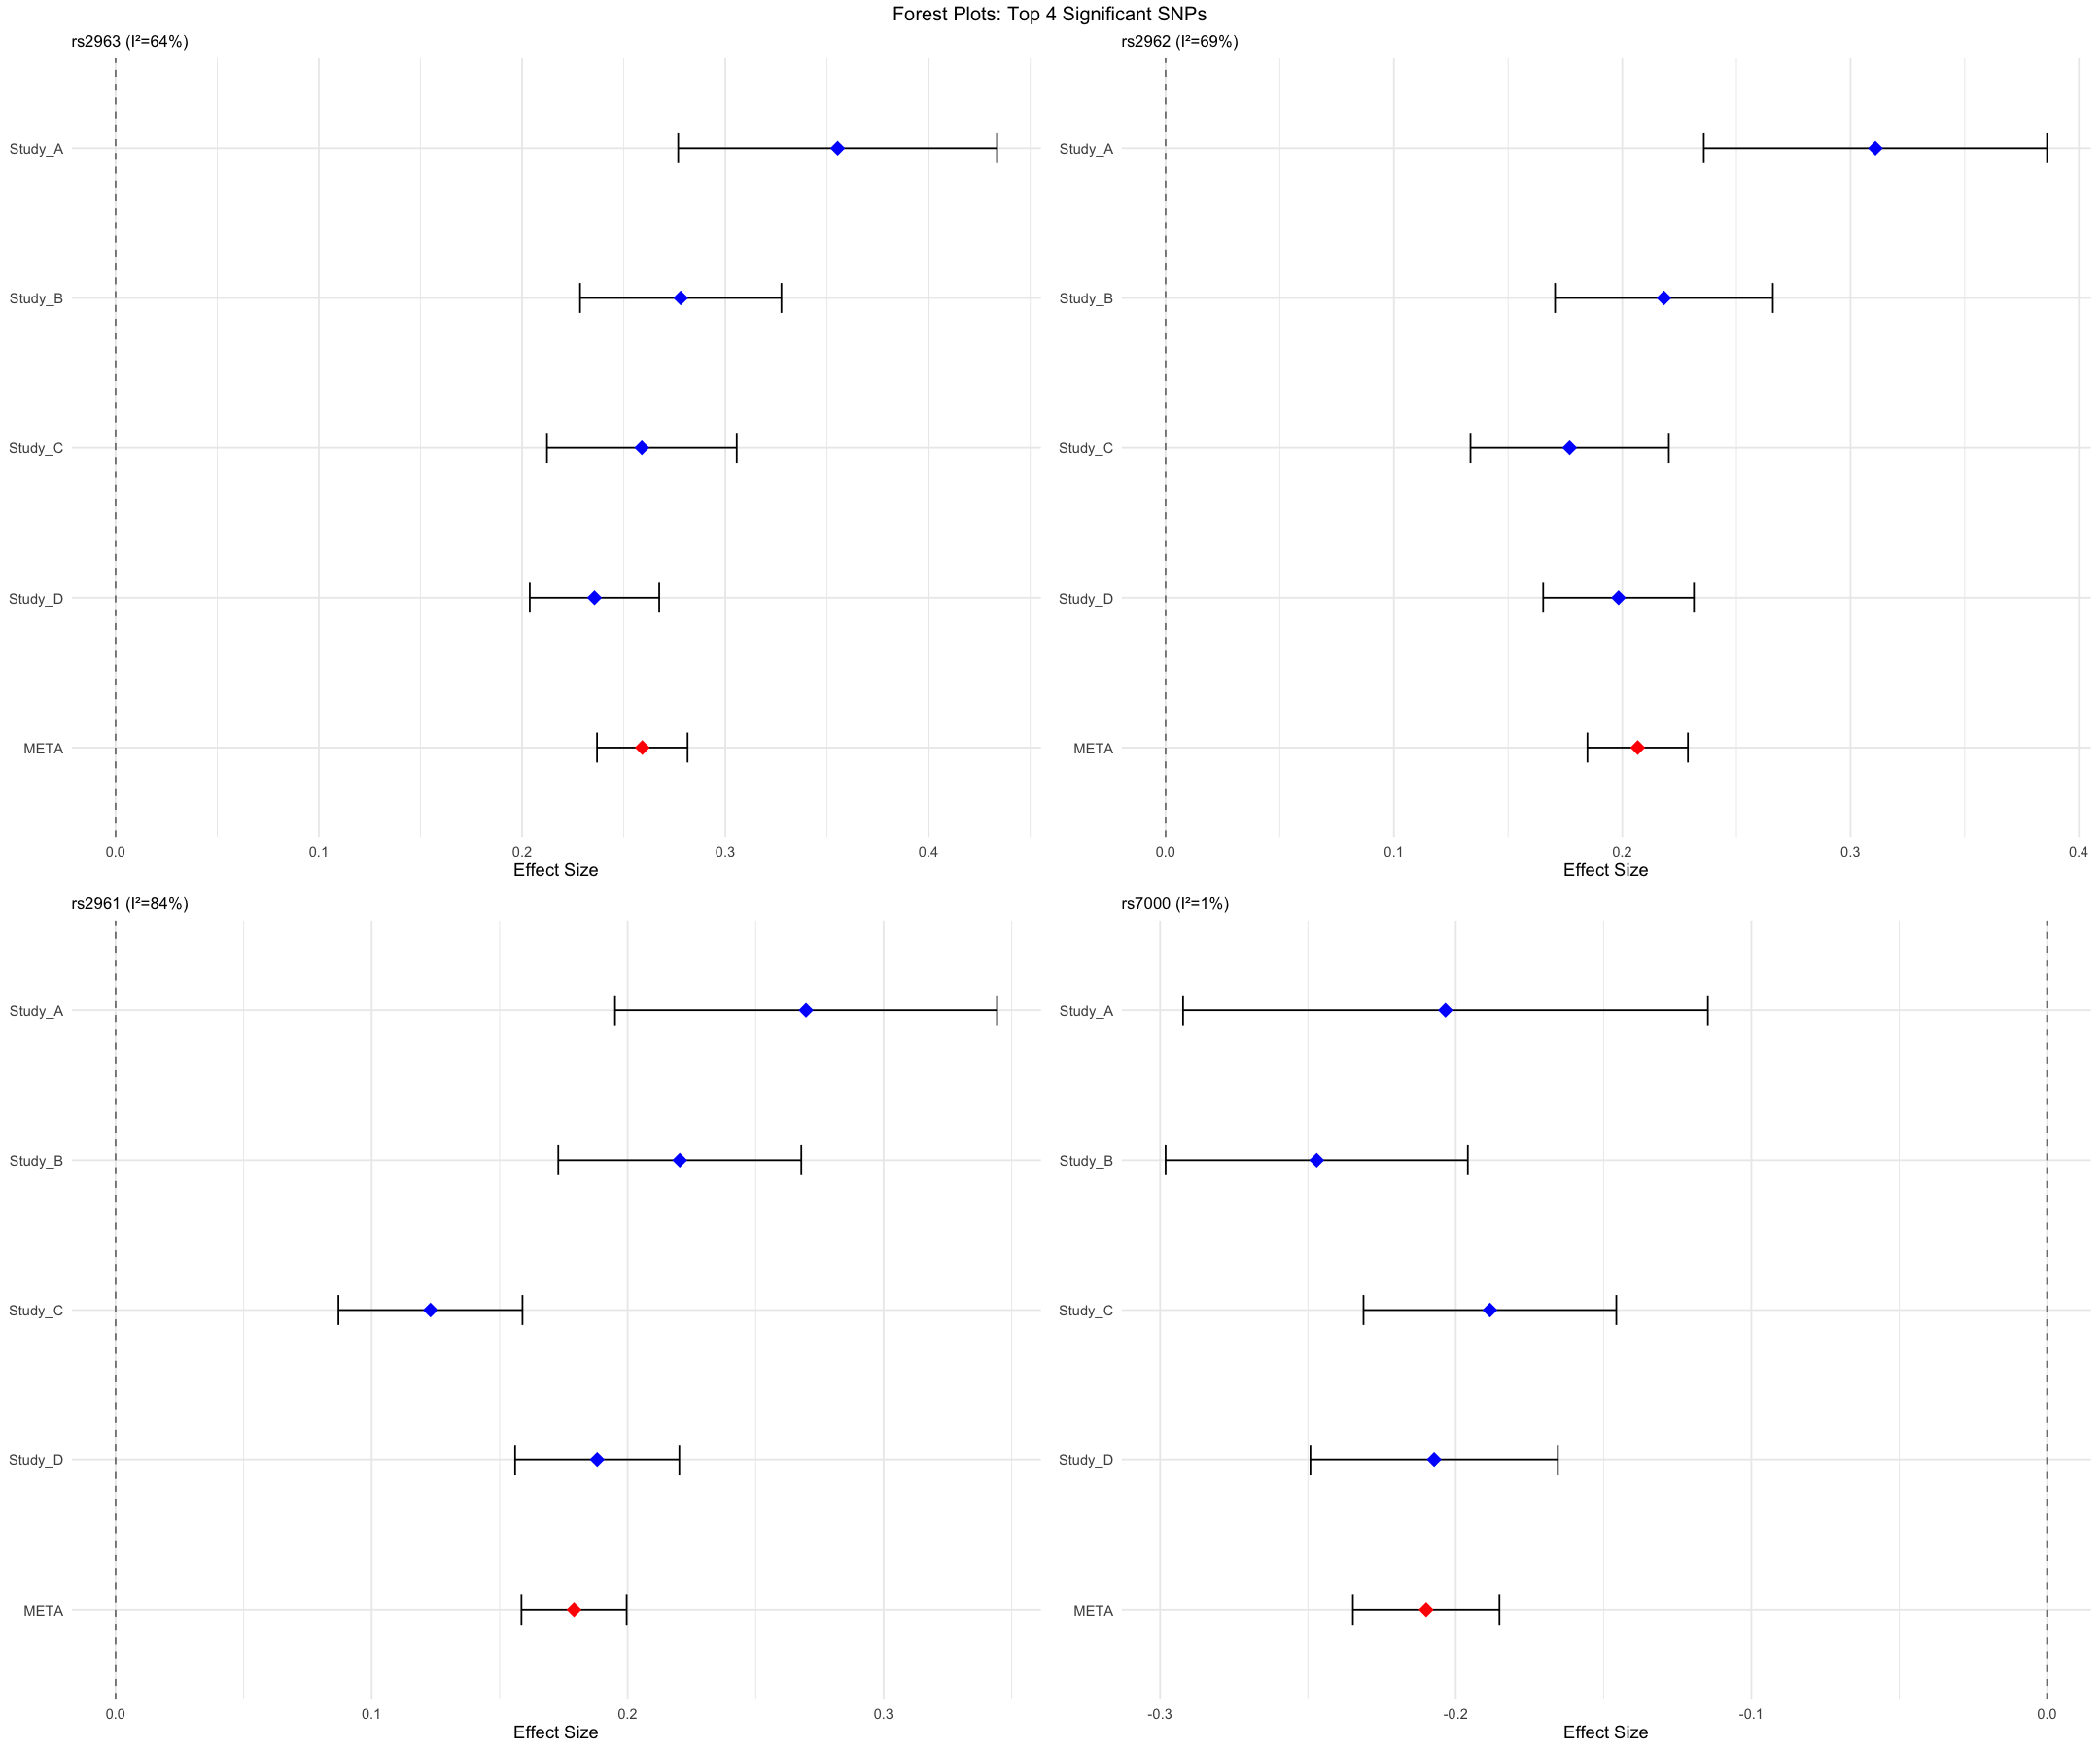

In [76]:
# Create forest plots for top 4 SNPs
if (nrow(significant_snps) == 0) {
  cat("No significant SNPs for forest plots.\n")
} else {
  top_4_snps <- significant_snps$SNP[1:min(4, nrow(significant_snps))]
  
  forest_plots <- lapply(top_4_snps, function(snp) {
    snp_data <- combined_results %>% filter(SNP == snp)
    meta_est <- meta_results_fe %>% filter(SNP == snp)
    
    forest_df <- snp_data %>%
      mutate(
        lower_ci = beta - 1.96 * se,
        upper_ci = beta + 1.96 * se
      ) %>%
      dplyr::select(study, beta, lower_ci, upper_ci)
    
    forest_df <- rbind(
      forest_df,
      data.frame(
        study = "META",
        beta = meta_est$beta_fe,
        lower_ci = meta_est$beta_fe - 1.96 * meta_est$se_fe,
        upper_ci = meta_est$beta_fe + 1.96 * meta_est$se_fe
      )
    )
    
    forest_df$study <- factor(forest_df$study, levels = rev(forest_df$study))
    
    ggplot(forest_df, aes(x = beta, y = study)) +
      geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
      geom_errorbarh(aes(xmin = lower_ci, xmax = upper_ci), height = 0.2) +
      geom_point(aes(color = study == "META"), size = 4, shape = 18) +
      scale_color_manual(values = c("blue", "red"), guide = "none") +
      theme_minimal() +
      labs(
        title = sprintf("%s (I²=%.0f%%)", snp, meta_est$I2),
        x = "Effect Size",
        y = NULL
      ) +
      theme(plot.title = element_text(size = 10))
  })
  
  # Arrange in grid
  grid.arrange(grobs = forest_plots, ncol = 2, 
               top = "Forest Plots: Top 4 Significant SNPs")
}

### Heterogeneity Visualization

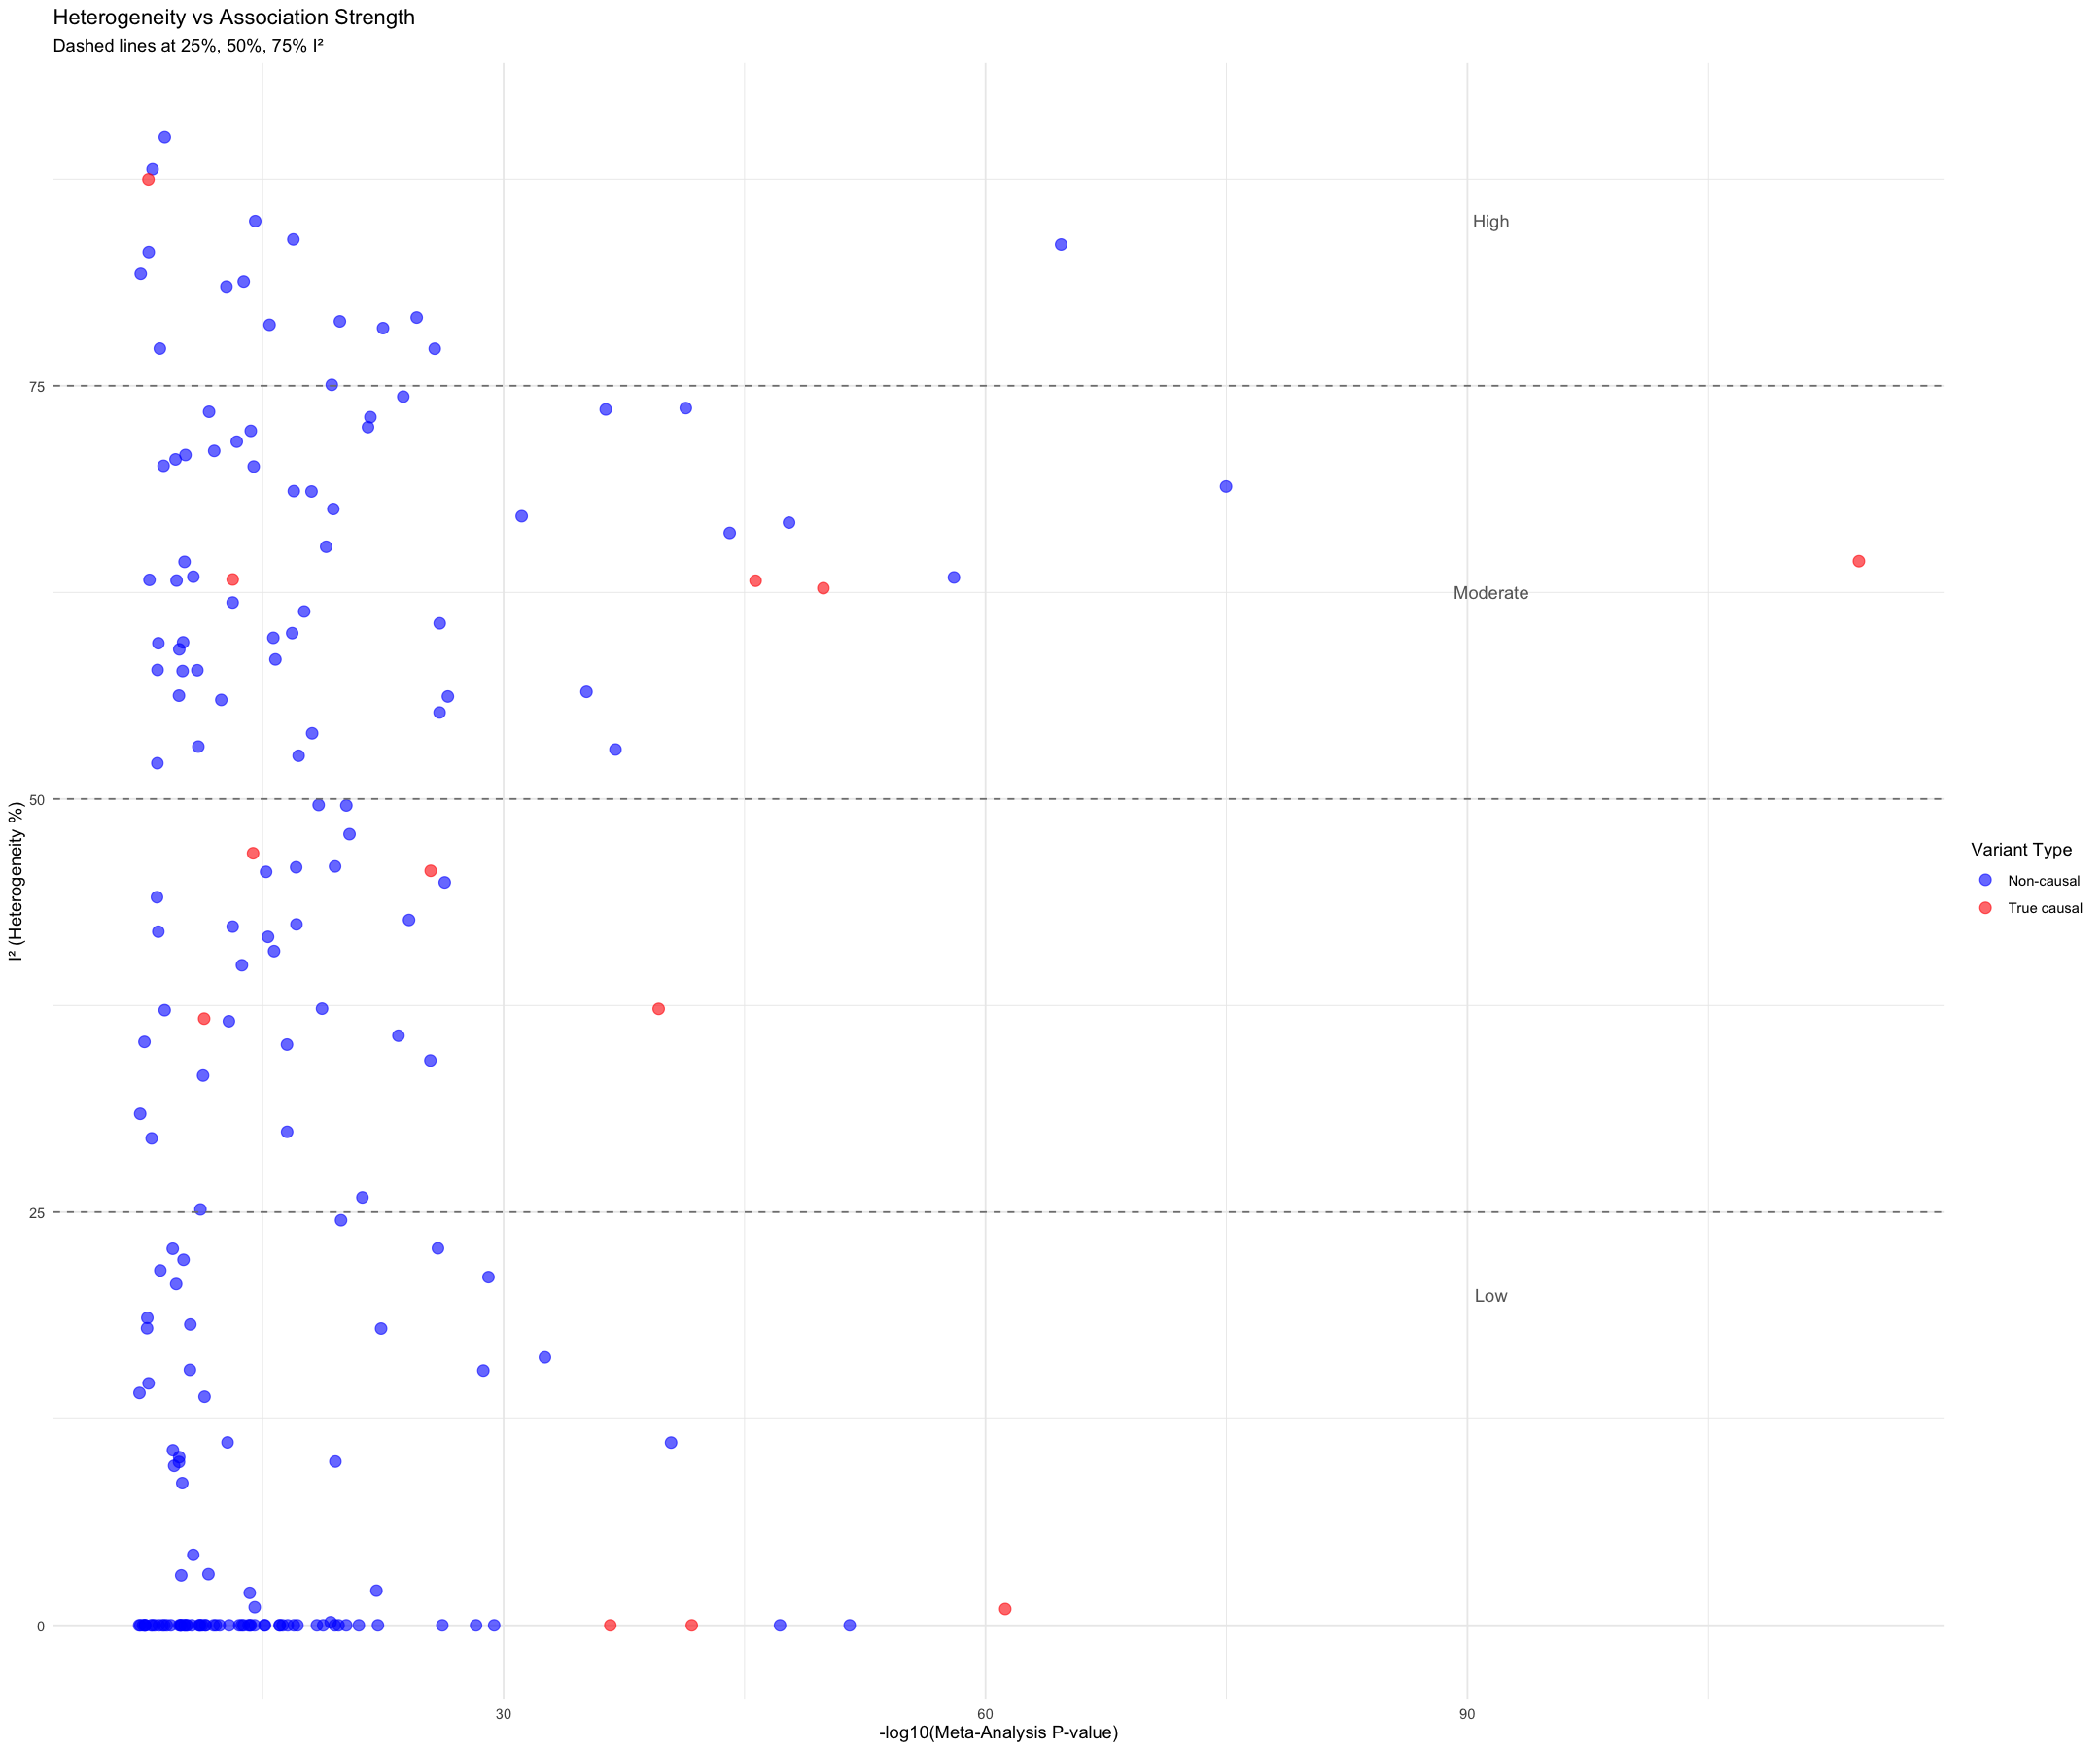

In [77]:
# I² vs -log10(p-value) scatter plot
if (nrow(significant_snps) == 0) {
  cat("No significant SNPs for heterogeneity plot.\n")
} else {
  print(ggplot(significant_snps, aes(x = -log10(p_fe), y = I2)) +
    geom_point(aes(color = is_causal), alpha = 0.6, size = 3) +
    geom_hline(yintercept = c(25, 50, 75), linetype = "dashed", color = "gray50") +
    scale_color_manual(values = c("blue", "red"), 
                       labels = c("Non-causal", "True causal"),
                       name = "Variant Type") +
    theme_minimal() +
    labs(
      title = "Heterogeneity vs Association Strength",
      subtitle = "Dashed lines at 25%, 50%, 75% I²",
      x = "-log10(Meta-Analysis P-value)",
      y = "I² (Heterogeneity %)"
    ) +
    annotate("text", x = max(-log10(significant_snps$p_fe)) * 0.8, y = 20, 
             label = "Low", color = "gray40") +
    annotate("text", x = max(-log10(significant_snps$p_fe)) * 0.8, y = 62.5, 
             label = "Moderate", color = "gray40") +
    annotate("text", x = max(-log10(significant_snps$p_fe)) * 0.8, y = 85, 
             label = "High", color = "gray40"))
}

### Volcano Plot: Meta-Analysis Results

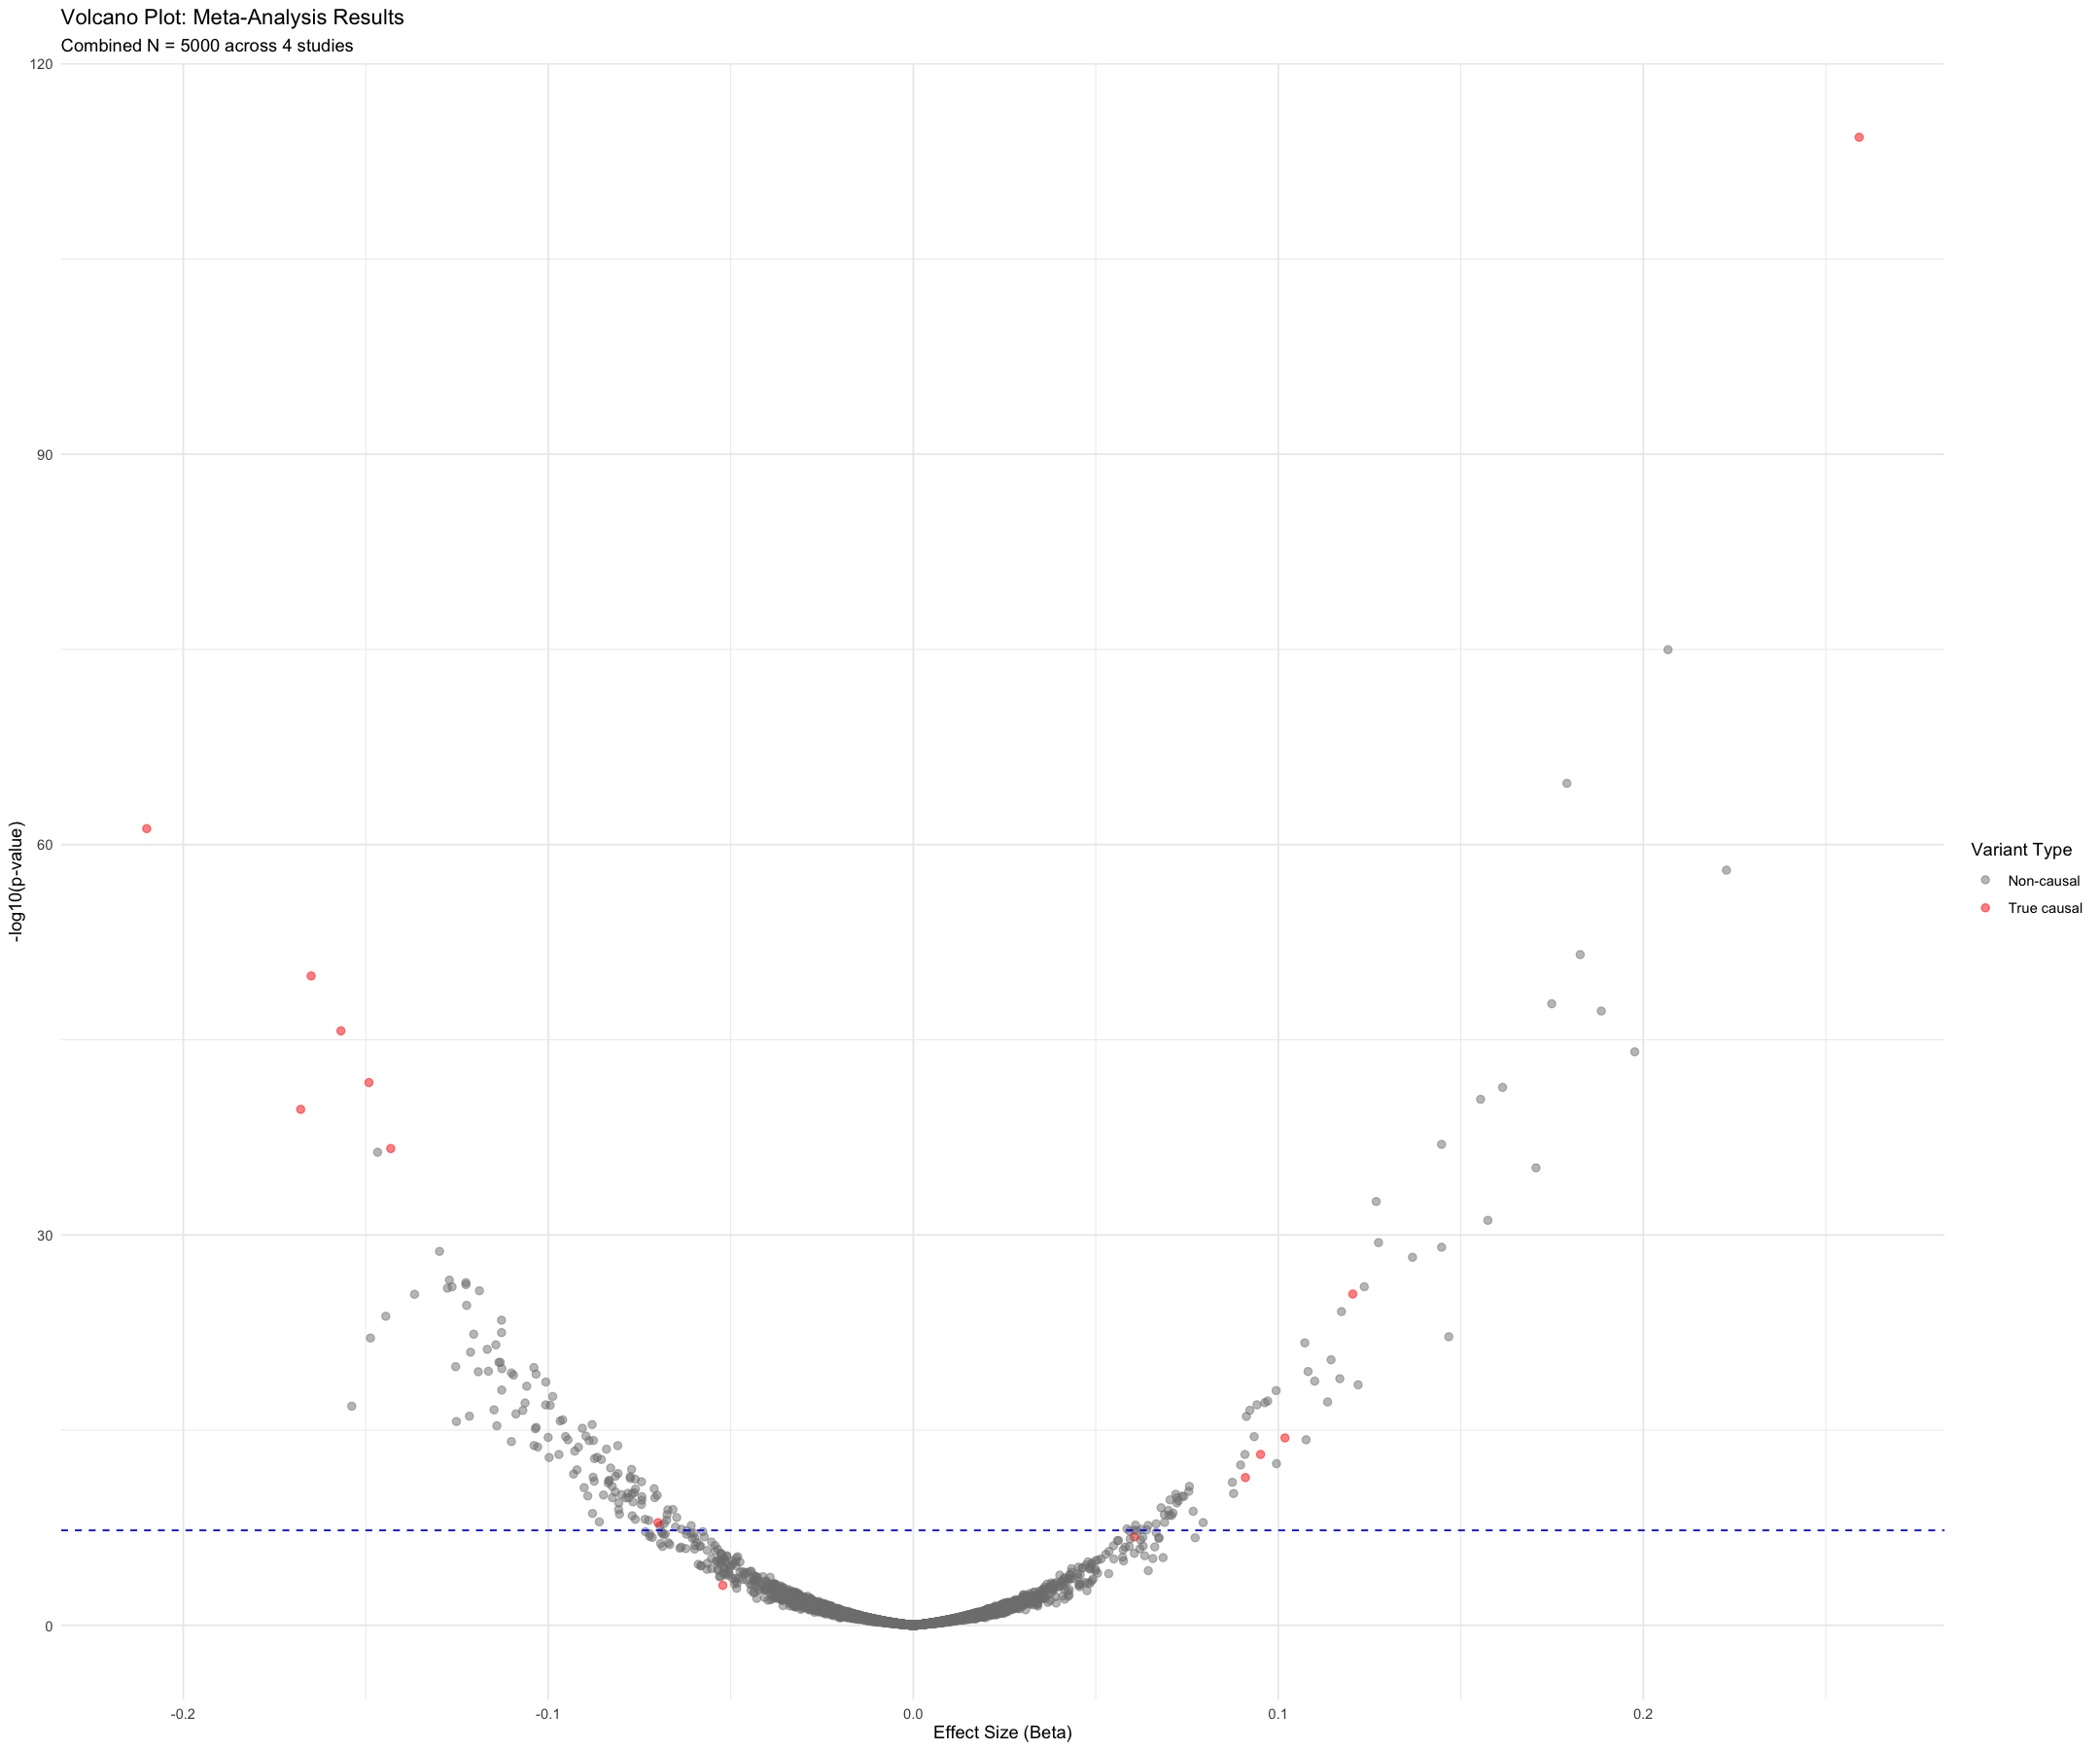

In [79]:
meta_results_fe %>%
  mutate(logP = -log10(p_fe)) %>%
  ggplot(aes(x = beta_fe, y = logP, color = is_causal)) +
  geom_point(alpha = 0.5, size = 2) +
  scale_color_manual(values = c("grey50", "red"),
                     labels = c("Non-causal", "True causal"),
                     name = "Variant Type") +
  geom_hline(yintercept = -log10(5e-8), linetype = "dashed", color = "blue") +
  theme_minimal() +
  labs(
    title = "Volcano Plot: Meta-Analysis Results",
    subtitle = sprintf("Combined N = %d across %d studies", sum(sample_sizes), n_studies),
    x = "Effect Size (Beta)",
    y = "-log10(p-value)"
  )

### Q-Q Plot: Meta-Analysis

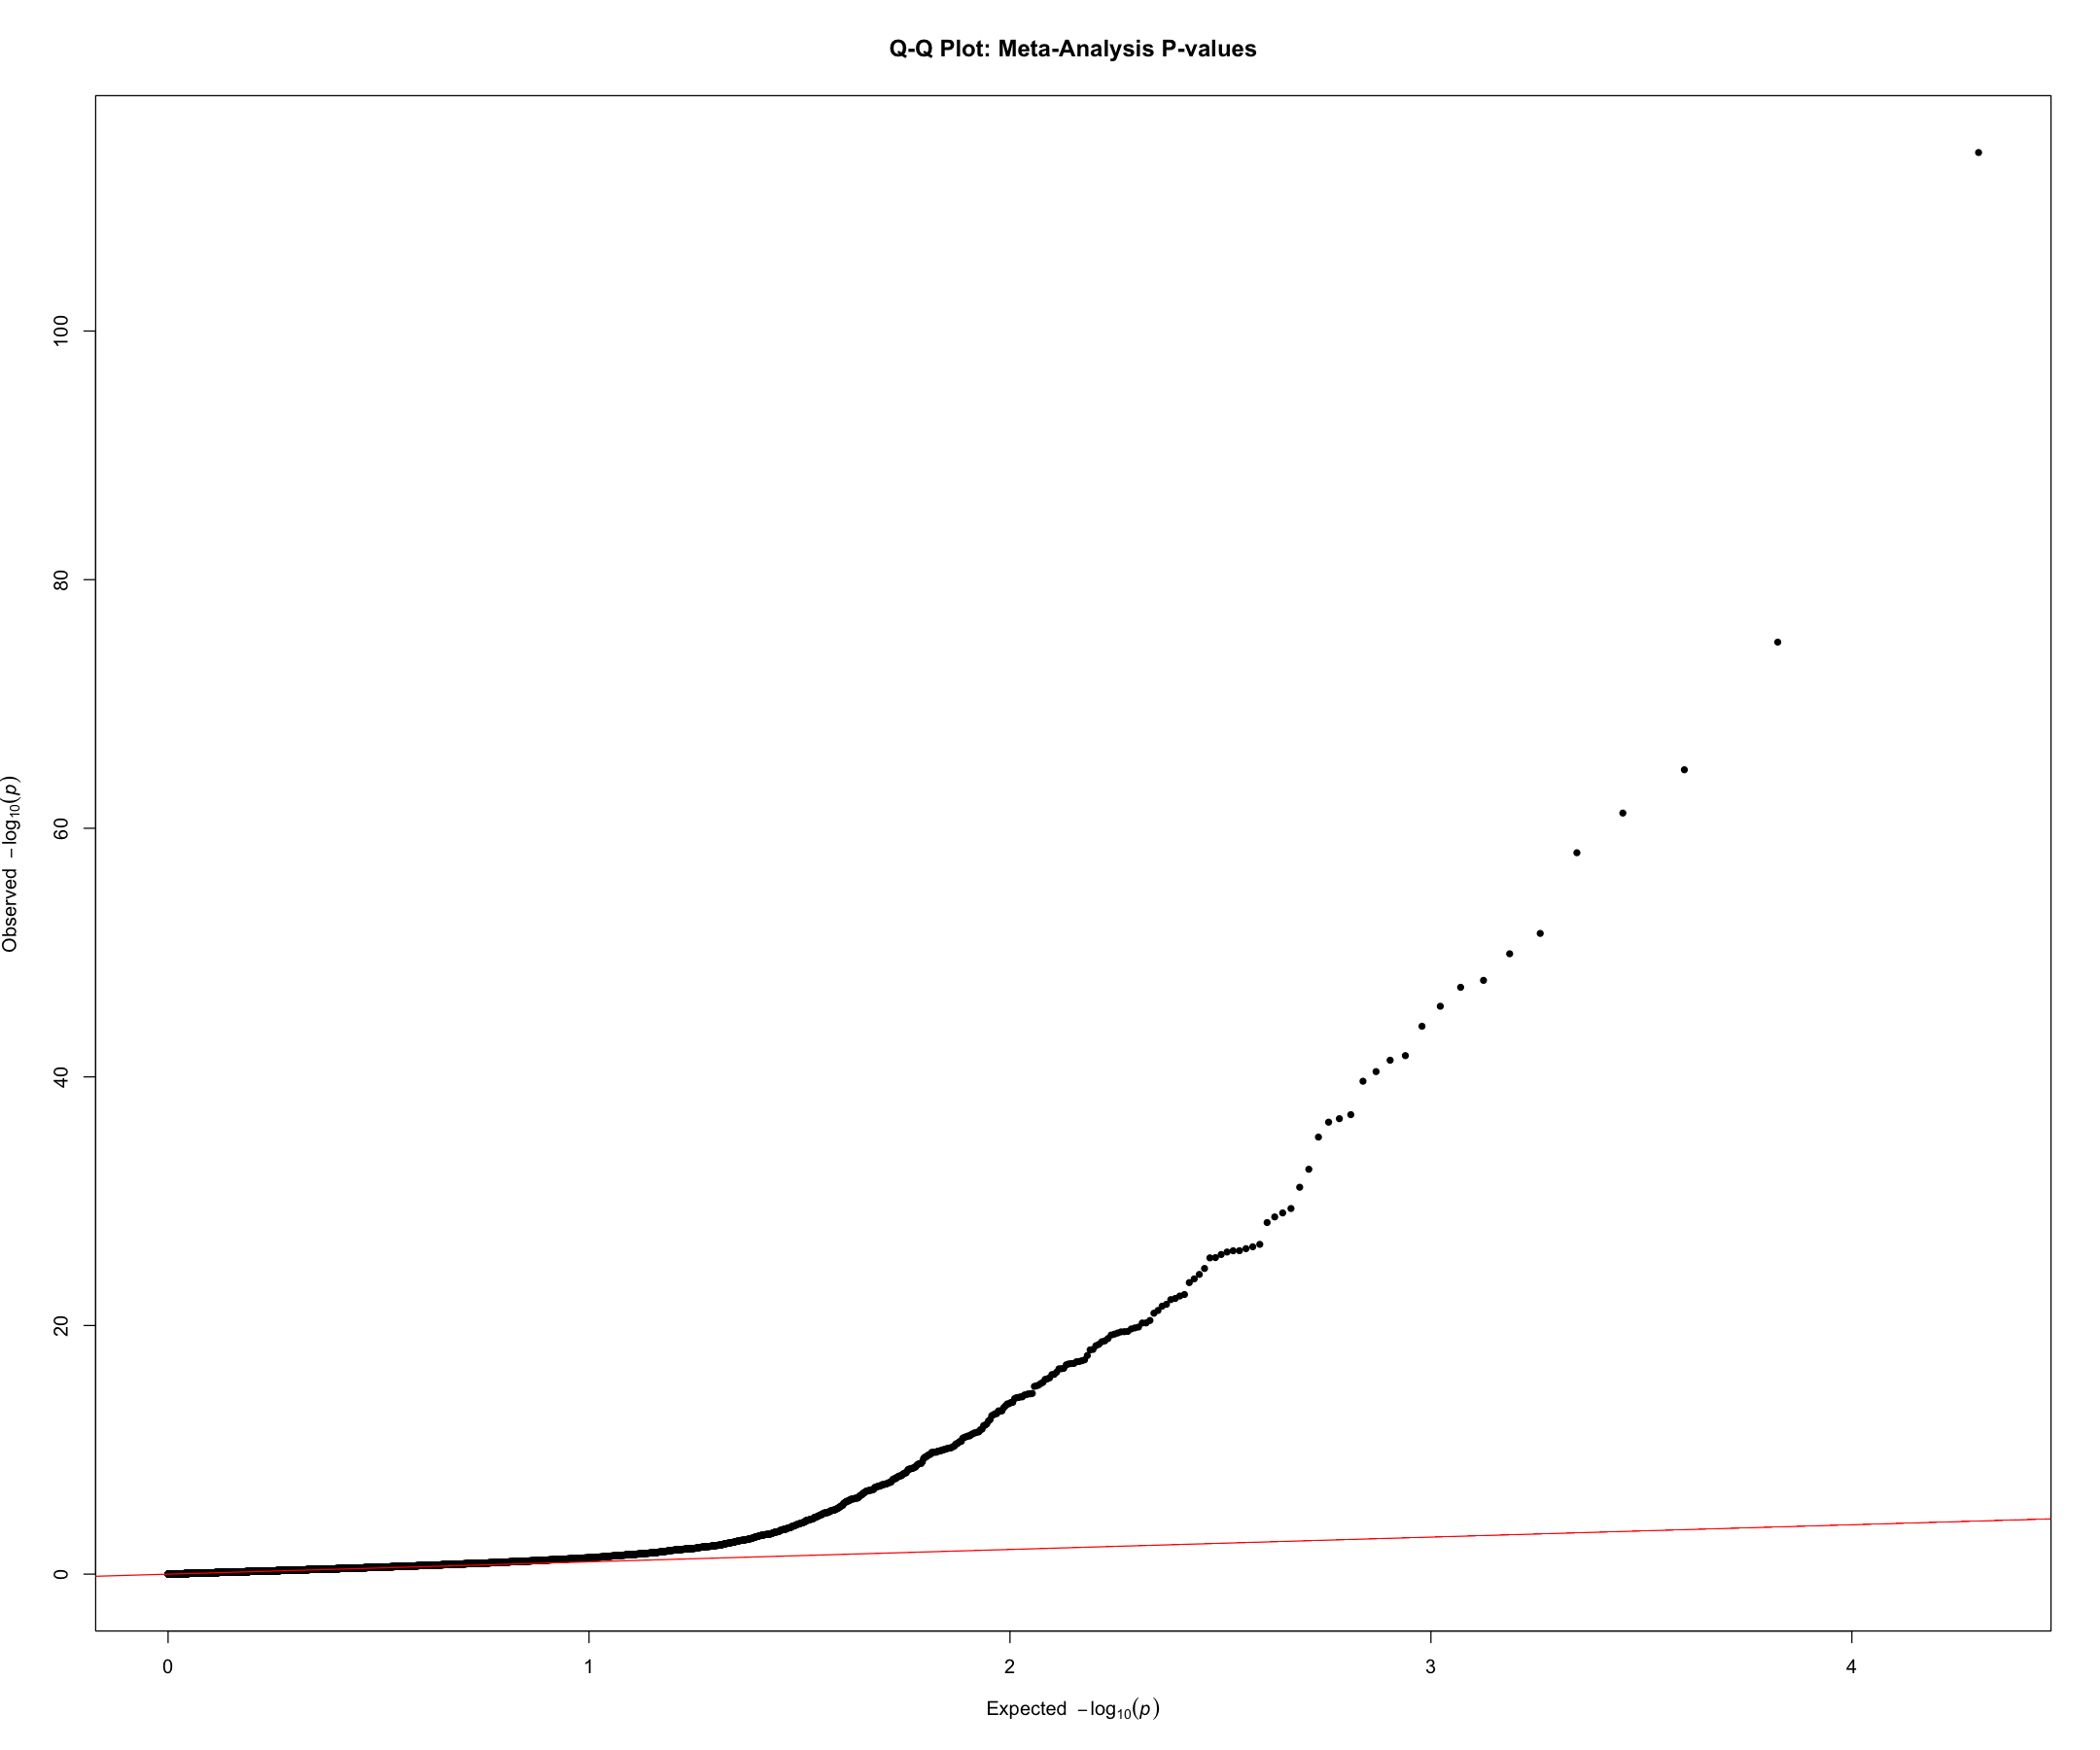

In [80]:
qq(meta_results_fe$p_fe, 
   main = "Q-Q Plot: Meta-Analysis P-values")

## Summary and Key Findings

In [82]:
cat("\n" , strrep("=", 60), "\n")
cat("         META-GWAS SIMULATION SUMMARY\n")
cat(strrep("=", 60), "\n\n")

cat("STUDY DESIGN:\n")
cat("  Number of independent studies:", n_studies, "\n")
cat("  Sample sizes:", paste(sample_sizes, collapse = ", "), "\n")
cat("  Total participants:", sum(sample_sizes), "\n")
cat("  SNPs analyzed:", n_snps, "\n")
cat("  True causal variants:", n_causal, "\n\n")

cat("INDIVIDUAL STUDY RESULTS:\n")
for (i in 1:n_studies) {
  detected <- sum(study_results_list[[i]]$is_causal & 
                  study_results_list[[i]]$p_value < 5e-8)
  cat(sprintf("  %s (N=%d): %d/%d causal variants detected (%.1f%%)\n",
              study_names[i], sample_sizes[i], detected, n_causal,
              100 * detected / n_causal))
}

meta_detected <- sum(meta_results_fe$is_causal & meta_results_fe$p_fe < 5e-8)
cat("\nMETA-ANALYSIS RESULTS:\n")
cat(sprintf("  Fixed-Effects: %d/%d causal variants detected (%.1f%%)\n",
            meta_detected, n_causal, 100 * meta_detected / n_causal))
cat("  Genome-wide significant SNPs:", sum(meta_results_fe$p_fe < 5e-8), "\n")
cat("  Mean I² (significant SNPs):", round(mean(significant_snps$I2), 1), "%\n")

# Calculate variants detected ONLY in meta-analysis
meta_only <- meta_results_fe %>%
  filter(is_causal & p_fe < 5e-8) %>%
  filter(!(SNP %in% unlist(lapply(study_results_list, function(df) 
    df$SNP[df$is_causal & df$p_value < 5e-8]))))

cat("\nPOWER IMPROVEMENT:\n")
cat("  Causal variants detected ONLY in meta-analysis:", nrow(meta_only), "\n")
cat("  Improvement over best single study:", 
    meta_detected - max(summary_table$Causal_Detected), "additional variants\n")

cat("\nHETEROGENEITY ASSESSMENT:\n")
cat("  SNPs with low heterogeneity (I² < 25%):", 
    sum(significant_snps$I2 < 25), "\n")
cat("  SNPs with moderate heterogeneity (25% ≤ I² < 75%):", 
    sum(significant_snps$I2 >= 25 & significant_snps$I2 < 75), "\n")
cat("  SNPs with high heterogeneity (I² ≥ 75%):", 
    sum(significant_snps$I2 >= 75), "\n")

cat("\n", strrep("=", 60), "\n")


         META-GWAS SIMULATION SUMMARY

STUDY DESIGN:
  Number of independent studies: 4 
  Sample sizes: 500, 1000, 1500, 2000 
  Total participants: 5000 
  SNPs analyzed: 10000 
  True causal variants: 15 

INDIVIDUAL STUDY RESULTS:
  Study_A (N=500): 5/15 causal variants detected (33.3%)
  Study_B (N=1000): 4/15 causal variants detected (26.7%)
  Study_C (N=1500): 7/15 causal variants detected (46.7%)
  Study_D (N=2000): 6/15 causal variants detected (40.0%)

META-ANALYSIS RESULTS:
  Fixed-Effects: 12/15 causal variants detected (80.0%)
  Genome-wide significant SNPs: 196 
  Mean I² (significant SNPs): 32.5 %

POWER IMPROVEMENT:
  Causal variants detected ONLY in meta-analysis: 12 
  Improvement over best single study: 5 additional variants

HETEROGENEITY ASSESSMENT:
  SNPs with low heterogeneity (I² < 25%): 95 
  SNPs with moderate heterogeneity (25% ≤ I² < 75%): 84 
  SNPs with high heterogeneity (I² ≥ 75%): 17 




## Insights gained from MetaGWAS:
- **Increased power to detect causal SNPs:** We saw that increasing SNP sample sizes directly leads to increase in liklihood of finding true causal SNPs, so it comes as no surprise that combining the results from multiple studies (effectively increasing sample size) results in finding the highest number of causal SNPs in MetaGWAS
- **Considerations about Heterogeneity**:
  - **Low I²**: Effect sizes consistent across studies → Fixed-effects is better
  - **High I²**: Substantial variation across studies → Consider random-effects or investigate causes
- **Why Heterogeneity even arises:**
  - Different ancestry backgrounds (MAF differences)
  - Different environmental exposures
  - Gene-environment interactions
  - Genotyping/imputation quality differences
- **Forest Plots**:
  - Show both individual study estimates and meta-analytic summary
  - Visualize consistency of effects across studies
- **Comparision with other GWAS methods:**
  - BioGWAS simulated data with no LD: isolated association signals with independent SNPs (not realistic at all)
  - BioGWAS simulated data with LD: Clustered signals, closer approximation to reality, Tag SNPs identified, but problem was that there was not enough causal SNPs being identified in a single study
  - Meta GWAS (on same data as above): Conducting more studies allows us to increase the power and identify more causal SNPs, assess heterogeneity etc.

## Personal Notes (for reference later)

#### When to Use Fixed-Effects vs Random-Effects
**Fixed-Effects:**
- Low heterogeneity (I² < 25%)
- Studies from same population
- Similar study designs
- More statistical power

**Random-Effects:**
- High heterogeneity (I² > 50%)
- Multi-ancestry studies
- Different study designs
- More conservative estimates

#### Quality Control in Real Meta-GWAS
1. **Harmonization**: Ensure same reference allele across studies
2. **Genomic control**: Correct for population stratification (λ adjustment)
3. **Imputation quality**: Filter SNPs with low imputation quality
4. **Sample overlap**: Account for related individuals across studies
5. **Winner's curse**: Correct for inflated effect sizes in discovery samples
